In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
pd.set_option('display.max_columns', None)

In [75]:
url = "https://data.cityofnewyork.us/resource/uip8-fykc.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,geocoded_column
0,318451126,2026-01-06T00:00:00.000,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,2026-01-03T00:00:00.000,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,2026-01-08T00:00:00.000,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,2026-01-07T00:00:00.000,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,2026-01-10T00:00:00.000,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


## Dataset Description

This dataset contains NYPD arrest records from NYC Open Data.  
It includes information such as arrest date, borough, offense type, age group, and demographics.  
For this project, I focus on the `arrest_boro` and `ofns_desc` columns to compare arrest patterns between Brooklyn and Queens.

The data used here is a sample of 50,000 records from the NYC Open Data API, not necessarily the full dataset.

In [76]:
df = df.replace("(null)", pd.NA)

In [77]:
df.isna().sum()

,0
arrest_key,0
arrest_date,0
pd_cd,2
pd_desc,12
ky_cd,12
ofns_desc,12
law_code,2
law_cat_cd,177
arrest_boro,0
arrest_precinct,0


# Goal: Compare Brooklyn and Queens arrest patterns using offense type

In [78]:
df.columns = df.columns.str.lower()
df = df.dropna(subset=["arrest_boro", "ofns_desc"])

comparison = df[df["arrest_boro"].isin(["K", "Q"])].copy()

comparison["borough"] = comparison["arrest_boro"].map({
    "K": "Brooklyn",
    "Q": "Queens"
})

brooklyn = comparison[comparison["borough"] == "Brooklyn"]
queens = comparison[comparison["borough"] == "Queens"]

print("Brooklyn arrests:", len(brooklyn))
print("Queens arrests:", len(queens))

Brooklyn arrests: 15409
Queens arrests: 10297


# We will compare boroughs using offense type

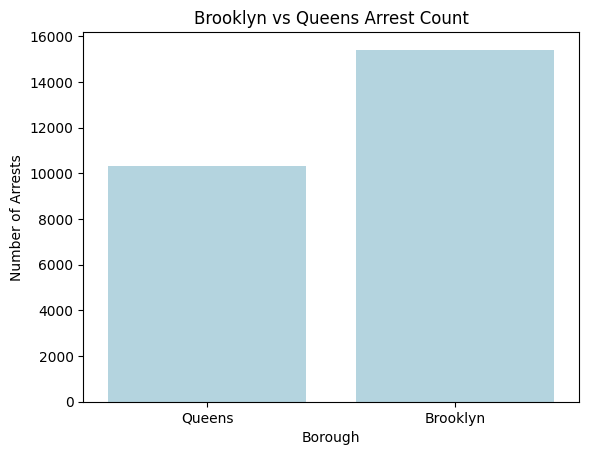

In [79]:
plt.figure()
sns.countplot(data=comparison, x="borough", color="lightblue")
plt.title("Brooklyn vs Queens Arrest Count")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")
plt.show()

In [80]:
print(df["ofns_desc"].value_counts().head(10))

ofns_desc
ASSAULT 3 & RELATED OFFENSES       6706
PETIT LARCENY                      4552
DANGEROUS DRUGS                    4162
FELONY ASSAULT                     3934
VEHICLE AND TRAFFIC LAWS           3482
MISCELLANEOUS PENAL LAW            3376
OTHER OFFENSES RELATED TO THEFT    2866
CRIMINAL MISCHIEF & RELATED OF     2101
OFFENSES AGAINST PUBLIC ADMINI     1990
ROBBERY                            1919
Name: count, dtype: int64


Because Brooklyn has more arrests overall, I compare offense types by percentage rather than only raw counts.

In [81]:
comparison["borough"] = comparison["arrest_boro"].map({
    "K": "Brooklyn",
    "Q": "Queens"
})

offense_pct = (
    comparison.groupby("borough")["ofns_desc"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name="percent")
)

offense_pct.head(10)

,borough,ofns_desc,percent
0,Brooklyn,ASSAULT 3 & RELATED OFFENSES,12.310987
1,Brooklyn,DANGEROUS DRUGS,8.475566
2,Brooklyn,MISCELLANEOUS PENAL LAW,8.112142
3,Brooklyn,FELONY ASSAULT,7.560517
4,Brooklyn,VEHICLE AND TRAFFIC LAWS,7.138685
5,Brooklyn,PETIT LARCENY,6.911545
6,Brooklyn,OTHER OFFENSES RELATED TO THEFT,6.807710
7,Brooklyn,OTHER STATE LAWS,5.360504
8,Brooklyn,CRIMINAL MISCHIEF & RELATED OF,4.309170
9,Brooklyn,DANGEROUS WEAPONS,4.192355


# Findings

Queens had a higher share of Assault 3 & Related Offenses, Petit Larceny, Felony Assault, Robbery, and Sex Crimes.

Brooklyn had a higher share of Dangerous Drugs, Other Offenses Related to Theft, Other State Laws, Dangerous Weapons, and Criminal Trespass.

# Top 5 offense types in Brooklyn and Queens

In [82]:
comparison.groupby("borough")["ofns_desc"].value_counts(normalize=True).groupby(level=0).head(5)

borough   ofns_desc                   
Brooklyn  ASSAULT 3 & RELATED OFFENSES    0.123110
          DANGEROUS DRUGS                 0.084756
          MISCELLANEOUS PENAL LAW         0.081121
          FELONY ASSAULT                  0.075605
          VEHICLE AND TRAFFIC LAWS        0.071387
Queens    ASSAULT 3 & RELATED OFFENSES    0.143925
          PETIT LARCENY                   0.085365
          MISCELLANEOUS PENAL LAW         0.085268
          FELONY ASSAULT                  0.085073
          VEHICLE AND TRAFFIC LAWS        0.068078
Name: proportion, dtype: float64

# Compare offense-type percentages in Brooklyn and Queens

In [83]:
pivot = (
    comparison.groupby("borough")["ofns_desc"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)

pivot.head()

ofns_desc,ADMINISTRATIVE CODE,ADMINISTRATIVE CODES,ALCOHOLIC BEVERAGE CONTROL LAW,ARSON,ASSAULT 3 & RELATED OFFENSES,BURGLAR'S TOOLS,BURGLARY,CANNABIS RELATED OFFENSES,CHILD ABANDONMENT/NON SUPPORT 1,CRIMINAL MISCHIEF & RELATED OF,CRIMINAL TRESPASS,DANGEROUS DRUGS,DANGEROUS WEAPONS,DISORDERLY CONDUCT,ESCAPE 3,FELONY ASSAULT,FOR OTHER AUTHORITIES,FORGERY,FRAUDS,FRAUDULENT ACCOSTING,GAMBLING,GRAND LARCENY,GRAND LARCENY OF MOTOR VEHICLE,HARRASSMENT 2,"HOMICIDE-NEGLIGENT,UNCLASSIFIE",INTOXICATED & IMPAIRED DRIVING,INTOXICATED/IMPAIRED DRIVING,JOSTLING,KIDNAPPING & RELATED OFFENSES,MISCELLANEOUS PENAL LAW,MOVING INFRACTIONS,MURDER & NON-NEGL. MANSLAUGHTE,OFF. AGNST PUB ORD SENSBLTY &,OFFENSES AGAINST PUBLIC ADMINI,OFFENSES AGAINST PUBLIC SAFETY,OFFENSES AGAINST THE PERSON,OFFENSES INVOLVING FRAUD,OFFENSES RELATED TO CHILDREN,OTHER OFFENSES RELATED TO THEFT,OTHER STATE LAWS,OTHER STATE LAWS (NON PENAL LAW),OTHER TRAFFIC INFRACTION,PETIT LARCENY,POSSESSION OF STOLEN PROPERTY,PROSTITUTION & RELATED OFFENSES,RAPE,ROBBERY,SEX CRIMES,THEFT-FRAUD,UNAUTHORIZED USE OF A VEHICLE,VEHICLE AND TRAFFIC LAWS
borough,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Brooklyn,0.136284,0.00649,0.097346,0.032449,12.310987,0.220650,2.349276,0.084366,0.025959,4.309170,2.011811,8.475566,4.192355,0.038938,0.006490,7.560517,0.181712,1.473165,0.668441,0.000000,0.681420,2.667272,0.421831,0.032449,0.00649,0.850153,0.103835,0.000000,0.058407,8.112142,0.207671,0.486729,1.888507,4.017133,0.025959,0.532157,0.785255,0.045428,6.807710,5.360504,0.168733,1.220066,6.911545,1.259004,0.051918,0.343955,3.491466,1.81063,0.058407,0.272568,7.138685
Queens,0.029135,0.00000,0.184520,0.009712,14.392542,0.252501,1.874332,0.417597,0.038846,4.360493,0.990580,5.574439,2.903758,0.000000,0.009712,8.507332,0.213654,1.272215,0.640963,0.058269,0.174808,3.146548,0.631252,0.029135,0.00000,1.961736,0.223366,0.019423,0.067981,8.526755,0.087404,0.524425,1.689813,4.447897,0.029135,0.398174,0.738079,0.058269,3.389337,3.777799,0.116539,0.971157,8.536467,1.437312,0.951734,0.456444,4.185685,4.52559,0.058269,0.301059,6.807808


In [84]:
diff = pivot.loc["Brooklyn"] - pivot.loc["Queens"]
diff.sort_values(ascending=False).head(10)

,0
ofns_desc,
OTHER OFFENSES RELATED TO THEFT,3.418373
DANGEROUS DRUGS,2.901127
OTHER STATE LAWS,1.582704
DANGEROUS WEAPONS,1.288597
CRIMINAL TRESPASS,1.021231
GAMBLING,0.506612
BURGLARY,0.474944
VEHICLE AND TRAFFIC LAWS,0.330877
OTHER TRAFFIC INFRACTION,0.248910


In [85]:
top_brooklyn = (
    offense_pct[offense_pct["borough"] == "Brooklyn"]
    .sort_values("percent", ascending=False)
    .head(10)
)

In [86]:
top_queens = (
    offense_pct[offense_pct["borough"] == "Queens"]
    .sort_values("percent", ascending=False)
    .head(10)
)

In [87]:
top_10 = pd.concat([
    top_brooklyn["ofns_desc"],
    top_queens["ofns_desc"]
]).unique()

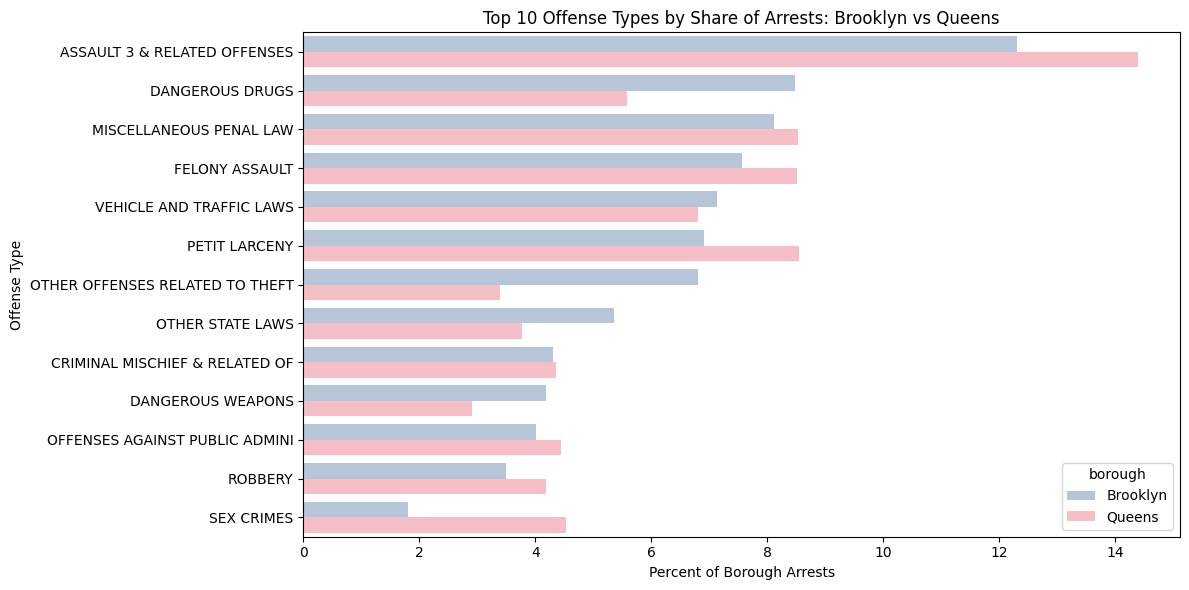

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=offense_pct[offense_pct["ofns_desc"].isin(top_10)],
    x="percent",
    y="ofns_desc",
    hue="borough",
    palette={"Brooklyn": "lightsteelblue", "Queens": "lightpink"}
)
plt.title("Top 10 Offense Types by Share of Arrests: Brooklyn vs Queens")
plt.xlabel("Percent of Borough Arrests")
plt.ylabel("Offense Type")
plt.tight_layout()
plt.show()

# Conclusion


Brooklyn had more total arrests than Queens in this sample, so offense patterns were compared using percentages. Assault 3 & Related Offenses was the most common category in both boroughs. Brooklyn had relatively higher shares of Dangerous Drugs and Other Offenses Related to Theft, while Queens had relatively higher shares of Assault 3 & Related Offenses, Petit Larceny, Felony Assault, Robbery, and Sex Crimes. Overall, the boroughs had similar leading offense categories, but the percentage differences show some variation in arrest patterns. These results reflect arrest activity, not total crime, and may be affected by policing practices, population size, and reporting patterns.

Arrests depend on:

* Policing intensity
* Enforcement priorities
* Demographics
* Not all crimes lead to arrests
